# 11. Fault reports (explainable diagnostics)

When the framework blocks a batch, this notebook turns that decision into a report a developer, QA, or business reader can act on: which check fired, which column is at fault, the visual evidence, and the developer action. It is powered by `src/diagnostics.py`.

Part A demonstrates all three fault types on deliberately corrupted batches, so each kind of issue is shown. Part B produces a real report for every batch the full-scale run genuinely flagged. All figures use the muted academic palette and are saved to `results/`.

In [1]:
import sys, os, textwrap
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from scipy import stats
import preprocessing as pp, framework as fw, diagnostics as dg

plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'savefig.dpi': 150,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8C8C8C'
INK, MUTE = '#2b2b2b', '#5f5f5f'
DATA = '../data/HI-Small_Trans.csv'
NUM = ['Amount Paid', 'Amount Received']
MISS = ['Receiving Currency', 'Payment Currency']
CHECK = {'anomaly': 'Unusual values', 'drift': 'Distribution change', 'missing': 'Missing information'}
ACTION = {'anomaly': "check the source feeding '{c}' for corrupted or fraudulent values",
          'drift': "check what changed upstream in '{c}'",
          'missing': "restore the missing '{c}' values before re-submitting"}

### Report rendering helpers

In [2]:
def summary_panel(ax, name, rep):
    ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    fail = rep['decision'] == 'FAIL'; accent = RED if fail else GREEN
    ax.add_patch(Rectangle((0, 9.0), 10, 1.0, fc=accent, ec='none'))
    ax.text(0.3, 9.5, name, color='white', fontsize=12.5, fontweight='bold', va='center')
    ax.text(9.7, 9.5, f"{'BLOCKED' if fail else 'PASSED'}  ·  {rep['combined']:.2f}", color='white',
            fontsize=10.5, fontweight='bold', va='center', ha='right')
    y = 8.1
    for dim in ['anomaly', 'drift', 'missing']:
        issue = rep['checks'][dim] >= 0.5; dot = RED if issue else GREEN
        ax.add_patch(plt.Circle((0.35, y), 0.11, color=dot))
        ax.text(0.7, y, CHECK[dim], fontsize=11, va='center', color=INK)
        ax.text(9.7, y, 'ISSUE' if issue else 'clear', fontsize=9.5, va='center', ha='right',
                color=RED if issue else GREY, fontweight='bold'); y -= 0.72
    if rep['findings']:
        top = rep['findings'][0]
        ax.add_patch(Rectangle((0, 0), 10, 4.7, fc='#f6f4ef', ec='#e2ddd2'))
        ax.text(0.3, 4.4, "Why it was blocked", fontsize=10.5, fontweight='bold', color=INK)
        ax.text(0.3, 3.98, textwrap.fill(top['detail'], 50), fontsize=9.0, color=INK, va='top')
        ax.text(0.3, 1.25, "Developer action", fontsize=10.5, fontweight='bold', color=INK)
        ax.text(0.3, 0.85, textwrap.fill(ACTION[top['dimension']].format(c=top['column']), 50),
                fontsize=9.0, color=INK, va='top')

def evidence_panel(ax, batch, reference, rep):
    if not rep['findings']:
        ax.axis('off'); ax.text(0.5, 0.5, 'no issue found', ha='center'); return
    top = rep['findings'][0]; dim, col = top['dimension'], top['column']
    if dim == 'drift':
        ref = np.log1p(reference[col].clip(lower=0)); cur = np.log1p(batch[col].clip(lower=0))
        bins = np.linspace(min(ref.min(), cur.min()), max(ref.max(), cur.max()), 55)
        ax.hist(ref, bins=bins, density=True, color=GREY, alpha=0.55, label='recent normal data')
        ax.hist(cur, bins=bins, density=True, color=RED, alpha=0.5, label='this batch')
        ax.set_title(f"'{col}': this batch's distribution has moved", fontsize=11.5, fontweight='medium')
        ax.set_xlabel(f'log({col})'); ax.set_ylabel('density'); ax.legend(frameon=False, fontsize=9.5)
    elif dim == 'anomaly':
        ref = np.log1p(reference[col].clip(lower=0)); cur = np.log1p(batch[col].clip(lower=0))
        thr = ref.mean() + 5*ref.std()
        ax.hist(cur, bins=60, color=BLUE, alpha=0.75)
        ax.axvline(thr, color=RED, ls='--', lw=1.5, label='extreme threshold (5 SD)')
        ax.axvspan(thr, cur.max()*1.02, color=RED, alpha=0.12)
        ax.text(0.97, 0.55, f'{int((cur>thr).sum())} extreme values', transform=ax.transAxes,
                ha='right', color=RED, fontsize=10.5, fontweight='bold')
        ax.set_title(f"'{col}': a clump of values sits far beyond normal", fontsize=11.5, fontweight='medium')
        ax.set_xlabel(f'log({col})'); ax.set_ylabel('count'); ax.legend(frameon=False, fontsize=9.5, loc='upper right')
    else:
        cols = MISS; rates = [batch[c].isna().mean()*100 for c in cols]; yp = list(range(len(cols)))
        ax.barh(yp, rates, color=[RED if r >= 2 else GREY for r in rates], height=0.5)
        ax.set_yticks([]); ax.set_ylim(-0.6, len(cols)-0.4)
        for yi, c, r in zip(yp, cols, rates):
            ax.text(max(r, 0.4)+0.8, yi, f"{c}:  {r:.0f}% missing", va='center',
                    fontsize=10.5, color=INK, fontweight='medium')
        ax.set_title("Missing values by column", fontsize=11.5, fontweight='medium')
        ax.set_xlabel('% of rows missing'); ax.set_xlim(0, 44)
        ax.grid(axis='x', ls=':', lw=0.7, color='#dddddd')

def render_fig(name, batch, reference, rep, save=None):
    fig = plt.figure(figsize=(13, 4.6)); gs = GridSpec(1, 2, width_ratios=[1, 1.35], wspace=0.28)
    summary_panel(fig.add_subplot(gs[0]), name, rep)
    evidence_panel(fig.add_subplot(gs[1]), batch, reference, rep)
    if save: fig.savefig(save, bbox_inches='tight')
    plt.show()

### Load the primary dataset and split reference / incoming

In [3]:
df = pp.load_transactions(DATA)
reference, incoming = pp.temporal_split(df, reference_days=3, max_days=10)
ref_sample = reference.sample(min(60000, len(reference)), random_state=42).reset_index(drop=True)
print('reference rows:', len(reference), '| incoming rows:', len(incoming))

reference rows: 2076752 | incoming rows: 3000485


## Part A: one report per fault type
Each batch is a real reference sample with one fault deliberately injected, so the report can show all three kinds of issue.

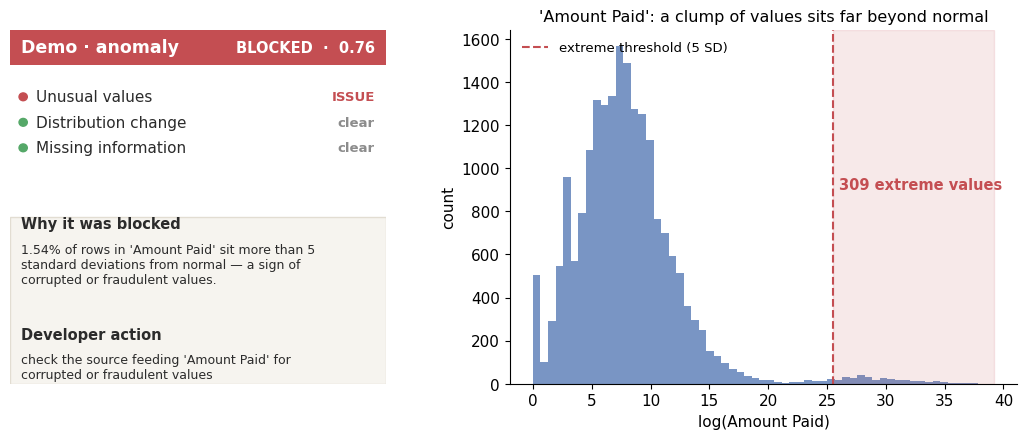

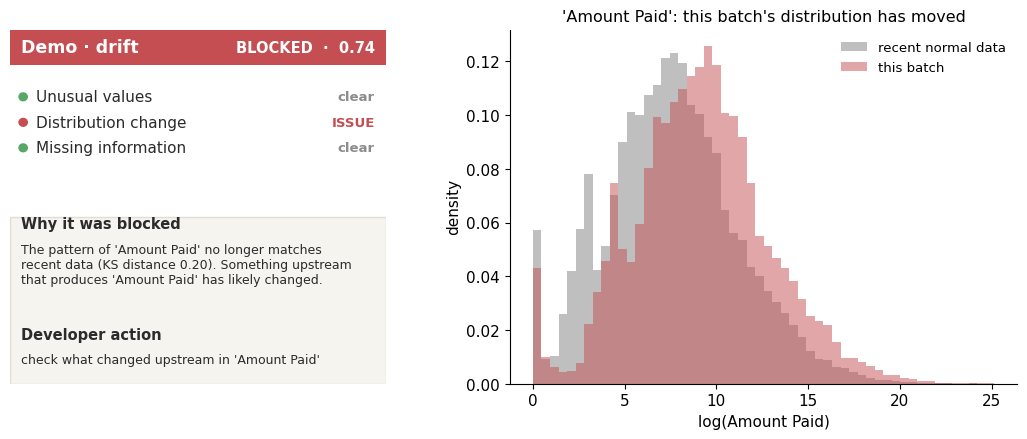

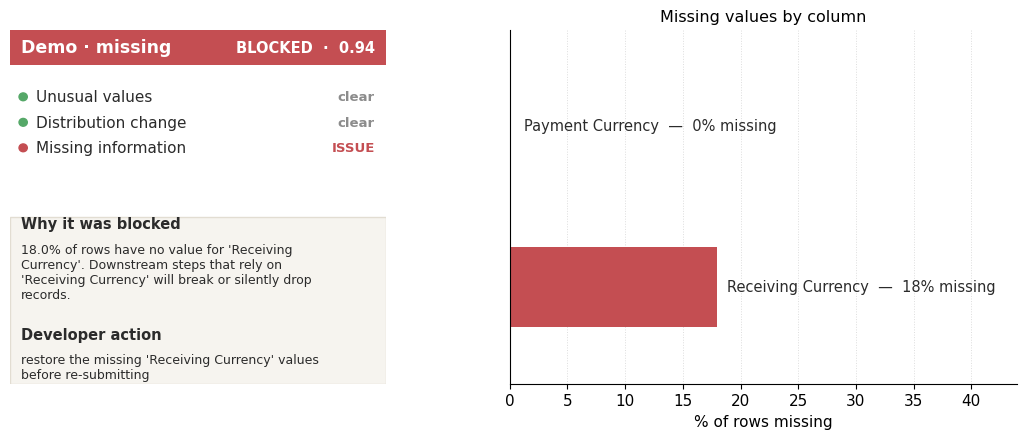

In [4]:
rng = np.random.default_rng(3)
def samp(n=20000):
    return reference.sample(min(n, len(reference)), random_state=int(rng.integers(1e9))).reset_index(drop=True)
b_anom = samp(); i = rng.choice(b_anom.index, 400, replace=False); b_anom.loc[i, 'Amount Paid'] *= 1e9
b_drift = samp(); b_drift['Amount Paid'] *= 5.0
b_miss = samp(); i = rng.choice(b_miss.index, 3600, replace=False); b_miss.loc[i, 'Receiving Currency'] = np.nan
for nm, b, tag in [('Demo · anomaly', b_anom, 'anomaly'),
                   ('Demo · drift', b_drift, 'drift'),
                   ('Demo · missing', b_miss, 'missing')]:
    rep = dg.diagnose(b, ref_sample, NUM, MISS)
    render_fig(nm, b, ref_sample, rep, save=f'../results/fault_demo_{tag}.png')

## Part B: real reports for the batches the full-scale run flagged
Re-runs the rolling gate over the whole stream, then reports each genuinely flagged batch against recent data.

flagged batches: [55, 56, 57]


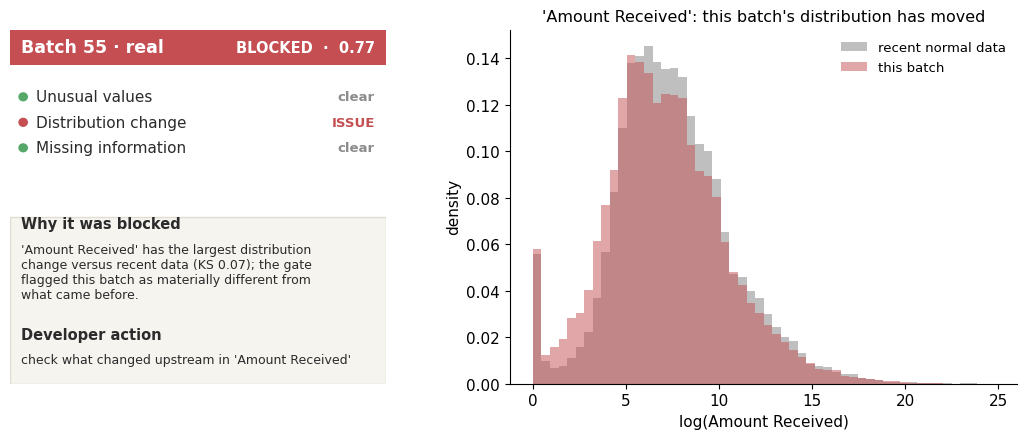

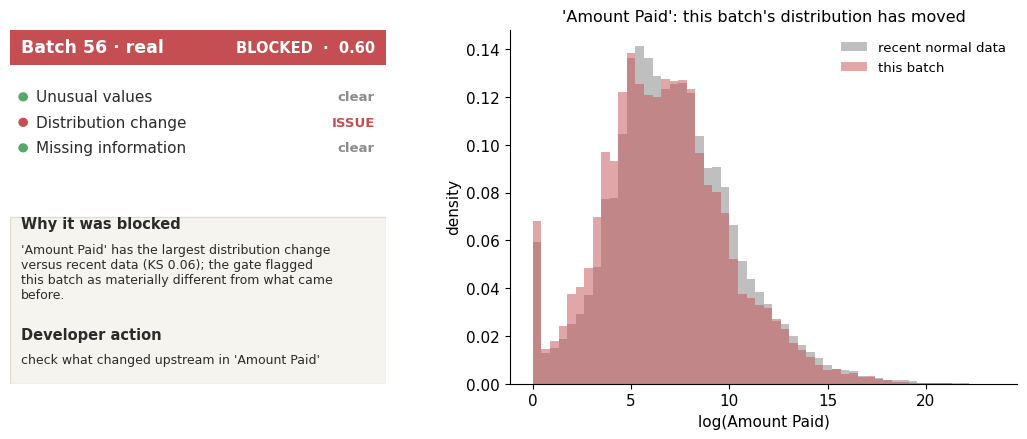

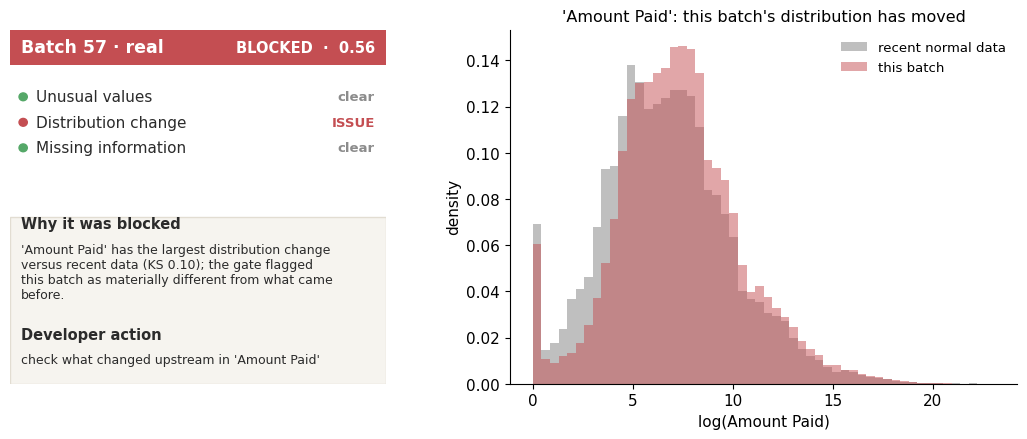

In [5]:
pipe, summary, run_stats = fw.run_pipeline(DATA, fw.IBM_CONFIG, batch_size=50_000,
                                           drift_reference='rolling', verbose=False)
flagged = summary[summary.decision == 'FAIL']['batch'].tolist()
print('flagged batches:', flagged)

def real_report(bi, batch, reference, score):
    kss = {c: stats.ks_2samp(np.log1p(reference[c].clip(lower=0).values),
                             np.log1p(batch[c].clip(lower=0).values))[0]
           for c in NUM if c in batch.columns and c in reference.columns}
    col = max(kss, key=kss.get); ks = kss[col]; sev = min(1.0, ks/0.4)
    rep = {'decision': 'FAIL', 'combined': float(score),
           'checks': {'anomaly': 0.0, 'drift': max(sev, 0.5), 'missing': 0.0},
           'findings': [{'dimension': 'drift', 'column': col, 'severity': sev,
                         'headline': f"'{col}' changed most vs recent data (KS={ks:.2f})",
                         'detail': (f"'{col}' has the largest distribution change versus recent "
                                    f"data (KS {ks:.2f}); the gate flagged this batch as materially "
                                    f"different from what came before.")}]}
    render_fig(f'Batch {bi} · real', batch, reference, rep,
               save=f'../results/fault_real_batch{bi}.png')

bs = 50_000
for bi in flagged:
    batch = incoming.iloc[bi*bs:(bi+1)*bs]
    ref_prev = incoming.iloc[max(bi-1, 0)*bs:bi*bs] if bi > 0 else reference.sample(bs, random_state=1)
    if len(ref_prev) == 0:
        ref_prev = reference.sample(min(bs, len(reference)), random_state=1)
    score = float(summary.loc[summary.batch == bi, 'combined'].iloc[0])
    real_report(bi, batch, ref_prev, score)

## Reading the reports

Each report has two halves: the plain-language verdict (which check fired, why the batch was blocked, and the developer action) and the visual evidence that backs it up. Part A shows the framework diagnosing each of the three fault types on deliberately corrupted batches. Part B explains every batch the real full-scale run flagged, showing which column changed most against recent data with the distribution shift plotted directly. This is the explainability layer: it lets a developer or QA justify a block to a business reader from the visuals alone.